# Análise Exploratória da Base - Comunicação de Acidente de Trabalho (CAT/INSS).

### Projeto: Análise e Modelagem Preditiva de Afastamentos por Burnout / Transtornos Mentais

- Etapa: Análise exploratória em busca de insights
- Status: Concluído.


### Visão Geral e Objetivos

O objetivo principal desta etapa é transformar os dados que temos em respostas para as nossas perguntas a respeito das principais caracteristicas e fatores que levam à sindrome de burnout. Mas antes precisamos fazer uma verificação macro para entender um pouco mais os perfis demográficos, setores mais afetados, localização e etc:

- **Perfil Demográfico:** Distribuição por **Gênero** e **Faixa Etária** dos trabalhadores com afastamento por Burnout.

- **Geografia do Esgotamento:** Mapeamento por **UF/Município** de maior incidência.

- **Setores Econômicos mais Afetados (CNAE):** Descobrir quais ramos de atividade concentram a maioria dos registros de CAT por Burnout.

- **Tendência Temporal:** Gráficos de linha mostrando se os registros de CAT por causas mentais estão subindo mês a mês.

- **Tipo de Acidente/Afastamento:** Verificar o tempo de afastamento e o impacto previdenciário.

Fonte dos dados brutos:
- https://dados.gov.br/dados/organizacoes/visualizar/instituto-nacional-do-seguro-social

- https://dados.gov.br/dados/conjuntos-dados/comunicacoes-de-acidente-de-trabalho-cat-plano-de-dados-abertos-jun-2023-a-jun-2025

In [ ]:
## Libs necessárias importadas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


print('✅ Tudo importado com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   seaborn {sns.__version__}')


✅ Tudo importado com sucesso!
   pandas  2.2.3
   numpy   2.1.3
   seaborn 0.13.2


In [ ]:
dados_burnout = pd.read_parquet('/content/df_burnout_tratado_atualizado.parquet')

dados_burnout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18706 entries, 0 to 18705
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   agente_causador       18706 non-null  object        
 1   data_acidente         18706 non-null  datetime64[ns]
 2   cbo_codigo            18706 non-null  object        
 3   cbo_descricao         18706 non-null  object        
 4   cid_codigo            18706 non-null  object        
 5   cid_descricao         18706 non-null  object        
 6   cnae_codigo           18706 non-null  int64         
 7   emitente_cat          18706 non-null  object        
 8   indica_obito          18706 non-null  object        
 9   municipio_empregador  18706 non-null  object        
 10  natureza_lesao        18706 non-null  object        
 11  origem_cadastramento  18706 non-null  object        
 12  parte_corpo_atingida  18706 non-null  object        
 13  genero          

## Análisando o Perfil Demográfico: Distribuição por Gênero e Faixa Etária dos trabalhadores com afastamento por Burnout.

           Total Casos  Percentual (%)
genero                                
Feminino         11665           62.36
Masculino         7041           37.64


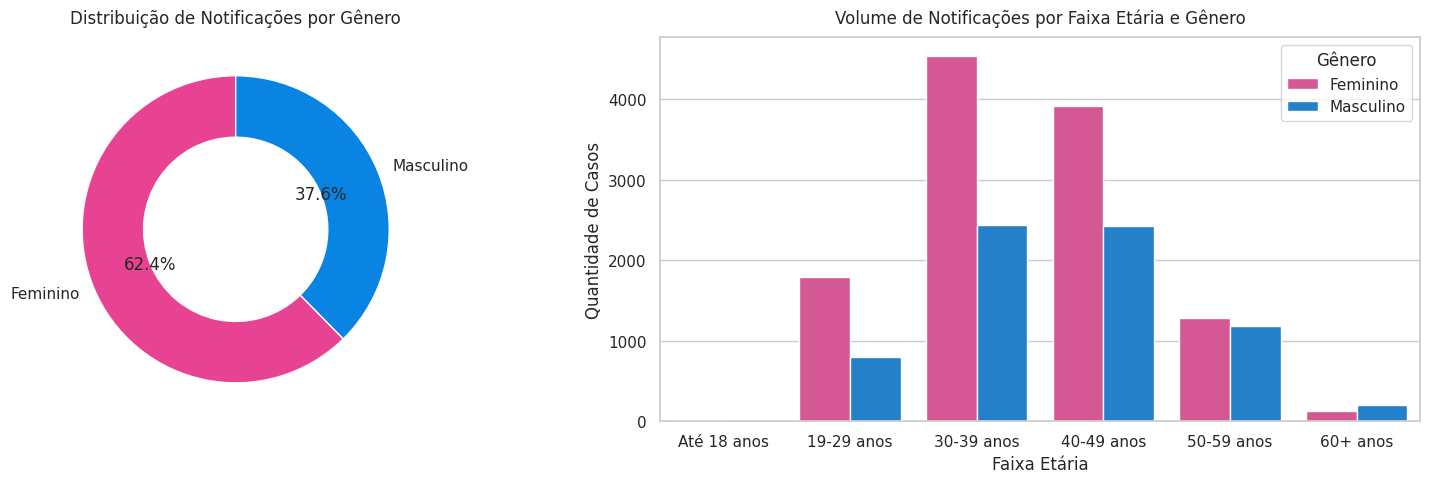

In [ ]:
# Configurando o Seaborn

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)


# FAIXAS ETÁRIAS
# Criando faixas de 10 em 10 anos padrão IBGE/Mercado
bins = [0, 18, 29, 39, 49, 59, 100]
labels = [
    'Até 18 anos',
    '19-29 anos',
    '30-39 anos',
    '40-49 anos',
    '50-59 anos',
    '60+ anos',
]

dados_burnout['faixa_etaria'] = pd.cut(
    dados_burnout['idade'], bins=bins, labels=labels, right=True
)

### Centralizando o total de casos por gênero
qtd_genero = dados_burnout['genero'].value_counts(dropna=False)
porcentagem_genero = dados_burnout['genero'].value_counts(
    normalize=True, dropna=False
) * 100

df_genero = pd.DataFrame({'Total Casos': qtd_genero, 'Percentual (%)': porcentagem_genero})
print(df_genero.round(2))

# Gráficos para a exploraçao visual

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Pizza/Rosca de Distribuição por Genero
colors_gen = ['#E84393', '#0984E3']
axes[0].pie(
    df_genero['Total Casos'],
    labels=df_genero.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_gen,
    wedgeprops=dict(width=0.4),
)
axes[0].set_title('Distribuição de Notificações por Gênero', fontsize=12, pad=10)

# Gráfico 2: Barras de Faixa Etária por Genero
sns.countplot(
    data=dados_burnout,
    x='faixa_etaria',
    hue='genero',
    palette={'Feminino': '#E84393', 'Masculino': '#0984E3'},
    ax=axes[1],
)
axes[1].set_title(
    'Volume de Notificações por Faixa Etária e Gênero', fontsize=12, pad=10
)
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Quantidade de Casos')
axes[1].legend(title='Gênero')

plt.tight_layout()
plt.show()

### A faixa etária para casos de Burnout registrado está entre 30 e 49 anos, afetando diretamente 62% das mulheres

- Isso pode ocorrer por diversos motivos, mulheres são e estão mais sobrecarregadas por ter muitas vezes duplas jornadas de trabalho, tanto fora quanto dentro de casa. Mas por outro lado tem o viés masculino de não procurar ajuda por não achar se tratar de algo tão grave e por isso ter menos registros em casos masculinos.

## Geografia do Esgotamento: Mapeando a doença por UF de maior incidência.

Aqui podemos dividir em duas perguntas?

- Visão relativa: Qual é a representatividade proporcional de cada estado?

- Visão Absoluta: Quais Ufs concentram o maior número bruto de casos de afastamento?

- Vamos análisar aqui especificamente a coluna "uf_empregador" que trata-se da sede da empresa contratante

In [ ]:
dados_burnout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18706 entries, 0 to 18705
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   agente_causador       18706 non-null  object        
 1   data_acidente         18706 non-null  datetime64[ns]
 2   cbo_codigo            18706 non-null  object        
 3   cbo_descricao         18706 non-null  object        
 4   cid_codigo            18706 non-null  object        
 5   cid_descricao         18706 non-null  object        
 6   cnae_codigo           18706 non-null  int64         
 7   emitente_cat          18706 non-null  object        
 8   indica_obito          18706 non-null  object        
 9   municipio_empregador  18706 non-null  object        
 10  natureza_lesao        18706 non-null  object        
 11  origem_cadastramento  18706 non-null  object        
 12  parte_corpo_atingida  18706 non-null  object        
 13  genero          

$$$$$$$$ Os 10 Estados com maior incidência de Burnout $$$$$$$$$$$
               UF  total_casos  porcentagem  porcentagem_acumulada
        São Paulo         7822    41.815460              41.815460
   Rio de Janeiro         2500    13.364696              55.180156
     Minas Gerais         1450     7.751524              62.931680
 Distrito Federal          984     5.260344              68.192024
Rio Grande do Sul          952     5.089276              73.281300
            Bahia          737     3.939912              77.221212
       Pernambuco          623     3.330482              80.551695
   Santa Catarina          528     2.822624              83.374318
           Paraná          471     2.517909              85.892227
            Ceará          404     2.159735              88.051962


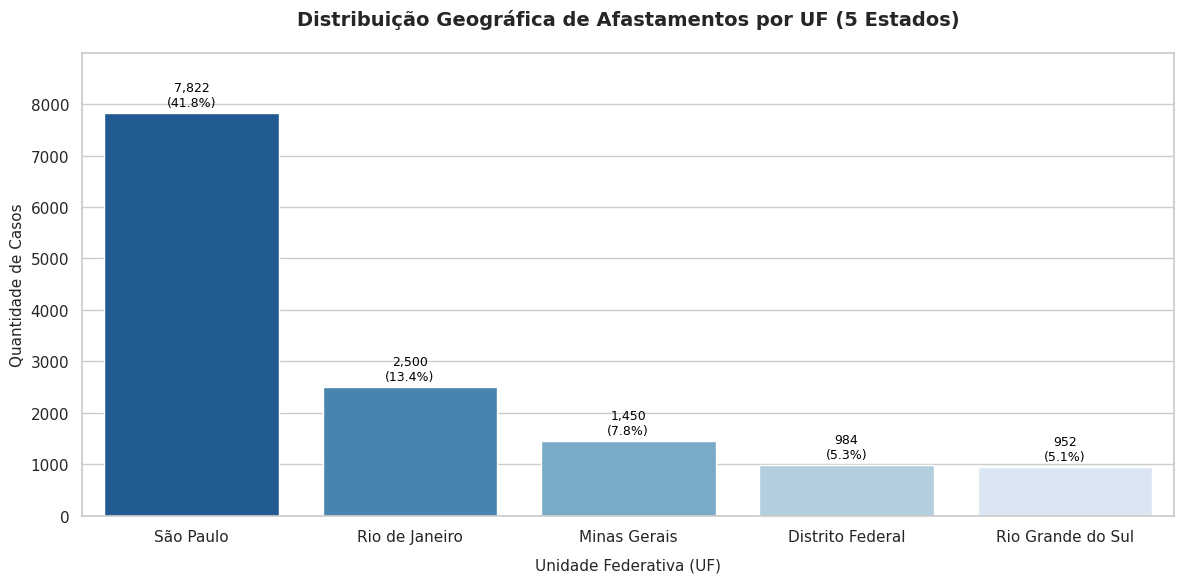

In [ ]:
#### Agregando por UF

uf_analise = (
    dados_burnout['uf_empregador']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'total_casos', 'uf_empregador': 'UF'})
)


# Calculo do percentual relativo

total_geral = uf_analise['total_casos'].sum()
uf_analise['porcentagem'] = (uf_analise['total_casos'] / total_geral) * 100
uf_analise['porcentagem_acumulada'] = uf_analise['porcentagem'].cumsum()

print('$$$$$$$$ Os 10 Estados com maior incidência de Burnout $$$$$$$$$$$')
print(uf_analise.head(10).to_string(index=False))

### Gráfico para as 15 UFS mais afetadas
plt.figure(figsize=(12, 6))

## Define os gradientes nas cores

palette = sns.color_palette('Blues_r', n_colors=len(uf_analise.head(5)))

ax = sns.barplot(
    data=uf_analise.head(5),
    x='UF',
    y='total_casos',
    palette=palette,
    hue='UF',
    legend=False,
)

# Adiciona os rótulos de contagem e porcentagem acima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_geral) * 100
        ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Distribuição Geográfica de Afastamentos por UF (5 Estados)',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.xlabel('Unidade Federativa (UF)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos', fontsize=11)
plt.ylim(0, uf_analise['total_casos'].max() * 1.15)  # Espaço para as anotações
plt.tight_layout()

plt.show()


Agora veremos especificamente a coluna uf_acidente que trata-se de quando o empregado precisa viajar pra outro estado, ou a empresa sede contrata para trabalhar de outro estado e a doença ocorre no estado em que ela está trabalhando no momento.

$$$$$$$$ Os 10 Estados com maior incidência de Burnout quando olhamos para quando o empregado não é contratado
para trabalhar especificamente no estado da sede da empresa contratante $$$$$$$$$$$
UF  total_casos  porcentagem  porcentagem_acumulada
MA         7932    42.403507              42.403507
TO         2520    13.471613              55.875120
RO         1462     7.815674              63.690794
CE         1366     7.302470              70.993264
RS          948     5.067893              76.061157
BA          733     3.918529              79.979686
PA          623     3.330482              83.310168
SC          528     2.822624              86.132792
RR          483     2.582059              88.714851
AM          397     2.122314              90.837165


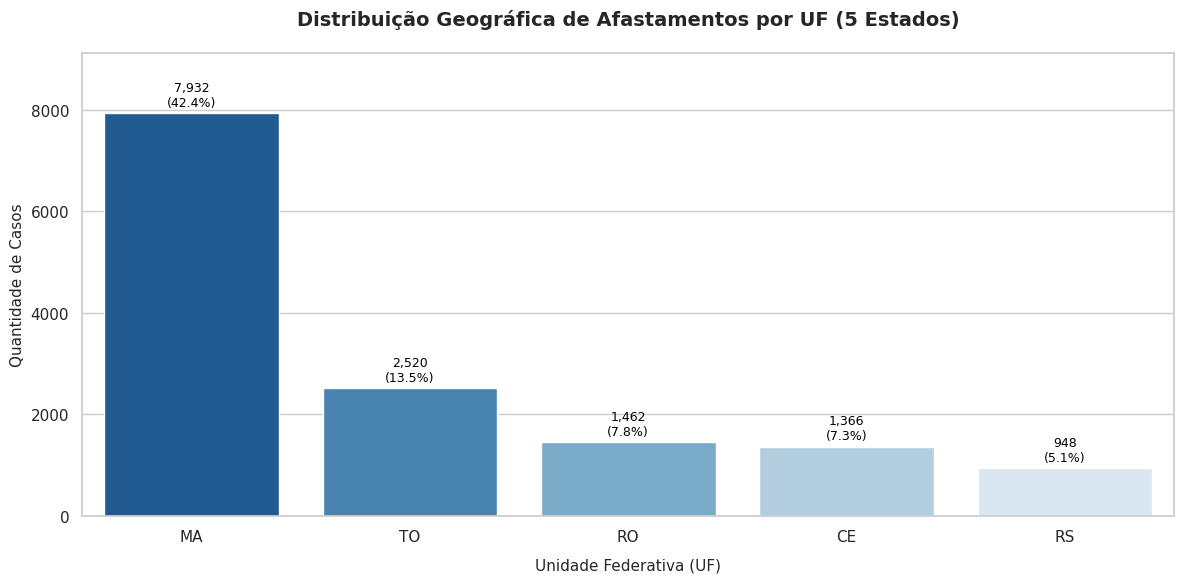

In [ ]:
#### Agregando por UF

uf_analise = (
    dados_burnout['uf_acidente']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'total_casos', 'uf_acidente': 'UF'})
)


# Calculo do percentual relativo

total_geral = uf_analise['total_casos'].sum()
uf_analise['porcentagem'] = (uf_analise['total_casos'] / total_geral) * 100
uf_analise['porcentagem_acumulada'] = uf_analise['porcentagem'].cumsum()

print('$$$$$$$$ Os 10 Estados com maior incidência de Burnout quando olhamos para quando o empregado não é contratado\n'
 'para trabalhar especificamente no estado da sede da empresa contratante $$$$$$$$$$$')
print(uf_analise.head(10).to_string(index=False))

### Gráfico para as 15 UFS mais afetadas
plt.figure(figsize=(12, 6))

## Define os gradientes nas cores

palette = sns.color_palette('Blues_r', n_colors=len(uf_analise.head(5)))

ax = sns.barplot(
    data=uf_analise.head(5),
    x='UF',
    y='total_casos',
    palette=palette,
    hue='UF',
    legend=False,
)

# Adiciona os rótulos de contagem e porcentagem acima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total_geral) * 100
        ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Distribuição Geográfica de Afastamentos por UF (5 Estados)',
    fontsize=14,
    pad=20,
    weight='bold',
)
plt.xlabel('Unidade Federativa (UF)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos', fontsize=11)
plt.ylim(0, uf_analise['total_casos'].max() * 1.15)  # Espaço para as anotações
plt.tight_layout()

plt.show()

- Temos então uma quebra de crença aqui:

A Sede (UF Empregador): SP com 41% (7.822 casos) e RJ em segundo lugar é a representação clássica do modelo corporativo brasileiro: **grandes multinacionais, bancos, tech e grandes indústrias sediadas nos eixos da Faria Lima/Paulista ou Rio.**

A Operação e o Risco Real (UF Acidente): O Maranhão com 42% (7.932 casos) e Tocantins com 2.520 liderando disparado **onde a CAT é registrada** de fato desmonta totalmente a tese de *"tem mais burnout em SP só porque tem mais gente"*.


Pode ser um alerta também a respeito da dinämica do trabalho desses estados mais afastados do centro, podendo indicar pode indicar indústrias extrativistas, grande agronegócio, obras de infraestrutura, logística intensiva ou operações terceirizadas/remotas com altíssima pressão física/mental e pouca estrutura de suporte.


vamos entender agora qual o munícipio de maior incidência no maranhão considerando que a incidencia é maior nesse estado:

Veremos qual tipo de operação no Maranhão e em Tocantins está gerando esse volume de afastamentos, cruzando o Município do Acidente com as nossas colunas limpas de CNAE (Setor Macro) e CBO (Grupo Macro).

In [ ]:
## Filtrando apenas para os estados líderes de ocorrência

df_ma_to = dados_burnout[dados_burnout['uf_acidente'].isin(['MA', 'TO'])]


## Agrupando por Estados, Municipios e Setores
municipios_risco = (
    df_ma_to.groupby(['uf_acidente', 'municipio_empregador', 'cnae_setor_macro'])
    .size()
    .reset_index(name='total_casos')
    .sort_values(by='total_casos', ascending=False)
    )

print('10 Municipios com maior incidencia e seu setor predominante')
print(municipios_risco.head(10).to_string(index=False))

10 Municipios com maior incidencia e seu setor predominante
uf_acidente municipio_empregador                 cnae_setor_macro  total_casos
         MA            São Paulo    Servicos_Financeiros_E_Bancos         2519
         MA            São Paulo     Outros_Servicos_E_Tecnologia          715
         MA               Osasco    Servicos_Financeiros_E_Bancos          654
         MA            São Paulo Teleatendimento_E_Servicos_Apoio          520
         MA            São Paulo  Correios_Logistica_E_Transporte          396
         TO        Rio de Janeir    Servicos_Financeiros_E_Bancos          258
         TO        Rio de Janeir     Outros_Servicos_E_Tecnologia          256
         MA            São Paulo        Comercio_Varejo_E_Atacado          236
         MA            São Paulo         Saude_E_Servicos_Sociais          219
         TO              Niterói    Servicos_Financeiros_E_Bancos          162


### Esse cruzamento nos mostra:

**Sede Corporativa (Município Empregador):** São Paulo, Osasco, Rio de Janeiro e Niterói concentram a gestão das empresas.

**Local Real do Afastamento (uf_acidente):** Maranhão e Tocantins.

**Setores Predominantes:** Serviços Financeiros e Bancos (liderando com 2.519 casos no MA por empresas de SP, mais 654 casos por empresas de Osasco — polo de grandes instituições financeiras) e Teleatendimento / Serviços de Apoio.

### E nos leva a levantar as seguintes hipóteses

- **Descentração Operacional e Terceirização / Call Centers / Polos Remotos:**
  - Grandes conglomerados bancários e empresas de tecnologia/serviços com sede em SP/RJ/Osasco **alocam pólos operacionais intensivos no Nordeste/Norte (MA e TO)**, onde a carga de trabalho, metas de atendimento e pressão por produtividade são elevadíssimas.

- **Trabalho Remoto ou Escalas em Campo:** Trabalhadores vinculados a CNPJs de capitais do Sudeste exercendo funções operacionais de alta demanda no MA/TO.

#### Vamos visualizar em um gráfico esse achado:

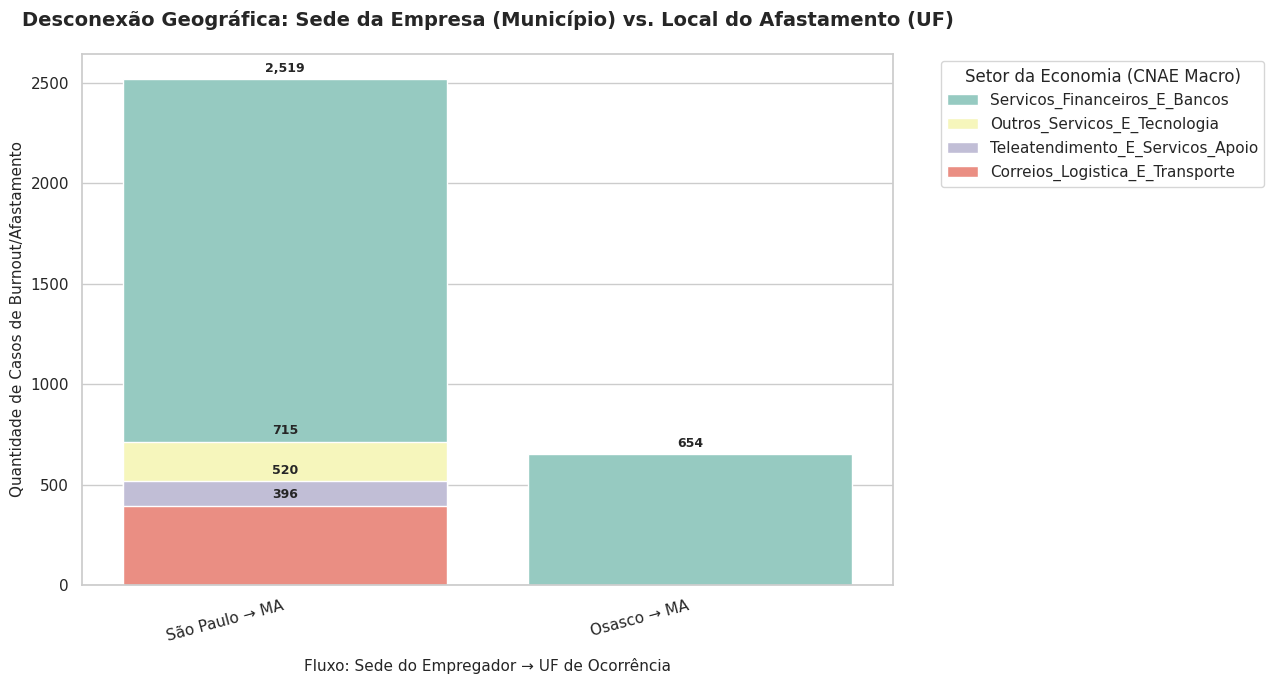

In [ ]:
### configurando o estilo do gráfico

sns.set_theme(style='whitegrid')
plt.figure(figsize=(13, 7 ))

## Pegando os cruzamentos mais expressivos
cruzamentos = municipios_risco.head(5).copy()

#Criando um rótulo combinado
cruzamentos['relacao'] = (
    cruzamentos['municipio_empregador']
    + ' → ' + cruzamentos['uf_acidente']
)

# Gráfico de barras

ax = sns.barplot(
    data = cruzamentos,
    x='relacao',
    y='total_casos',
    hue='cnae_setor_macro',
    dodge=False,
    palette='Set3',
)

## Adiciona valores no topo das barras
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height):,}',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
            xytext=(0, 3),
            textcoords='offset points',


    )

plt.title('Desconexão Geográfica: Sede da Empresa (Município) vs. Local do Afastamento (UF)',
fontsize=14,
pad=20,
weight='bold',
)
plt.xlabel('Fluxo: Sede do Empregador → UF de Ocorrência', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Casos de Burnout/Afastamento', fontsize=11)
plt.legend(title='Setor da Economia (CNAE Macro)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

plt.show()

2519 pessoas contratadas no centro SP e trabalham no Maranhão fizeram o registro.

- Vamos visualizar quem são os profissionais, cargos e funções estão sendo mais afetados e impactados nesses pólos descentralizados?

In [ ]:
### Filtrando a base focando no fluxo cruzado do polo (sede: `sao paulo/RJ --> Operação: Ma, TO)

coluna_cbo = ('cbo_grupo_macro' if 'cbo_grupo_macro' in df_ma_to.columns else 'cbo_linha')

filtro_polo = ((df_ma_to['uf_acidente'].isin(['MA', 'TO']))
& (
    df_ma_to['municipio_empregador'].isin(
        ['São Paulo', 'Osasco', 'Rio de Janeiro', 'Niteroi']
    )
))

df_polo = df_ma_to[filtro_polo]


### Agrupando pela ocupação e setor macro

cargos_principais = (
    df_polo.groupby([coluna_cbo, 'cnae_setor_macro'])
    .size()
    .reset_index(name='total_casos')
    .sort_values(by='total_casos', ascending=False)
    .head(5)
)

print('####### 5 Cargos mais afetados nos pólos MA/TO (sede SP/RJ) ########')
print(cargos_principais.to_string(index=False))


####### 5 Cargos mais afetados nos pólos MA/TO (sede SP/RJ) ########
                           cbo_grupo_macro                cnae_setor_macro  total_casos
Profissionais_Especialistas_Nivel_Superior   Servicos_Financeiros_E_Bancos         1450
               Gestores_Diretores_Gerentes   Servicos_Financeiros_E_Bancos          899
      Servicos_Administrativos_Atendimento   Servicos_Financeiros_E_Bancos          675
      Servicos_Administrativos_Atendimento Correios_Logistica_E_Transporte          258
Profissionais_Especialistas_Nivel_Superior    Outros_Servicos_E_Tecnologia          207


- Profissionais de Serviços financeiros lideram as 3 primeiras colocações onde profissionais especialistas de nível superior, Gestores, Diretores, Gerentes  e serviços administrativos dentro do setor financeiro são os mais afetados, tendo seus registros da doença concentrado no estado de Maranhão e Tocantis.

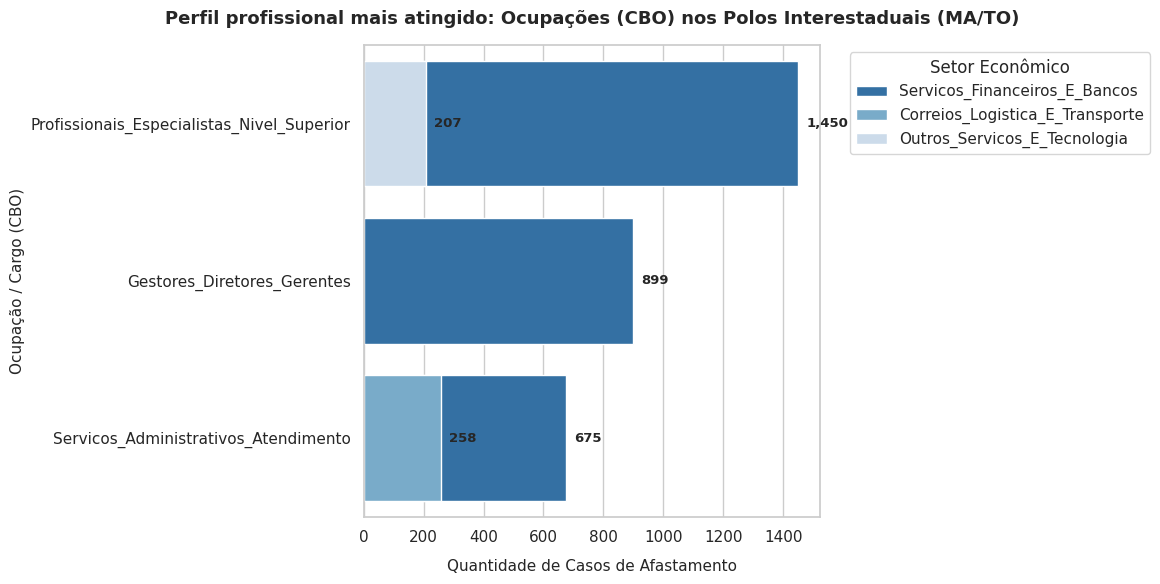

In [ ]:
### Visualizando essa informação

plt.figure(figsize=(12, 6))
sns.set_theme(style='whitegrid')

ax = sns.barplot(
    data=cargos_principais,
    x='total_casos',
    y=coluna_cbo,
    hue='cnae_setor_macro',
    dodge=False,
    palette='Blues_r',
)

# Rótulos nas barras
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}',
            (width, p.get_y() + p.get_height() / 2.0),
            xytext=(6, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=9.5,
            weight='bold',
        )

plt.title(
    'Perfil profissional mais atingido: Ocupações (CBO) nos Polos Interestaduais (MA/TO)',
    fontsize=13,
    weight='bold',
    pad=15,
)
plt.xlabel('Quantidade de Casos de Afastamento', fontsize=11, labelpad=10)
plt.ylabel('Ocupação / Cargo (CBO)', fontsize=11)
plt.legend(title='Setor Econômico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

## Os dados nos contam que:

- Pressão por metas executivas e riscos financeiros:

  - Especialistas e Gestores enfrentam forte cobrança por rentabilidade, gestão de portfólios regionais, expansão de crédito e compliance em operações de grande porte.

  - A responsabilidade decisória combinada com o fuso/distância da matriz (SP/RJ) gera uma carga cognitiva e estresse contínuo sobre a liderança e os analistas seniores.

- Carga dupla da gestão à distância:

  - Gerentes e diretores alocados ou responsáveis por operações no MA/TO costumam responder diretamente à diretoria em SP/RJ sob metas corporativas agressivas onde com certeza a logistica e dinâmica de SP difere completamente dos estados do MA e TO, ao mesmo tempo em que gerenciam a pressão operacional na ponta.

-----



## Análise temporal

- Como temos na base dados de registros de 2023 até o momento atual 2026 vamos com os gráficos tentar responder a seguinte pergunta:

  - O volume de afastamentos por **Burnout e transtornos mentais** está crescendo, estável ou caindo ao longo dos anos (2023 a 2026)?

In [ ]:
#### Convertendo e extraindo o ano e o mês utilizando a data_acidente

col_data = 'data_acidente'
dados_burnout[col_data] = pd.to_datetime(dados_burnout[col_data], errors='coerce')


### filtrando pra o intervalo de interesse

df_temporal = dados_burnout[(dados_burnout[col_data].dt.year >= 2023) &
                            (dados_burnout[col_data].dt.year <= 2026)].copy()

## Coluna de ano_mes para a linha do tempo
df_temporal['ano_mes'] = df_temporal[col_data].dt.to_period('M')

### Agrupando as contagens por mês
evolucao_mensal = (
    df_temporal.groupby('ano_mes')
    .size()
    .reset_index(name='total_casos')
)
evolucao_mensal['ano_mes_str'] = evolucao_mensal['ano_mes'].astype(str)




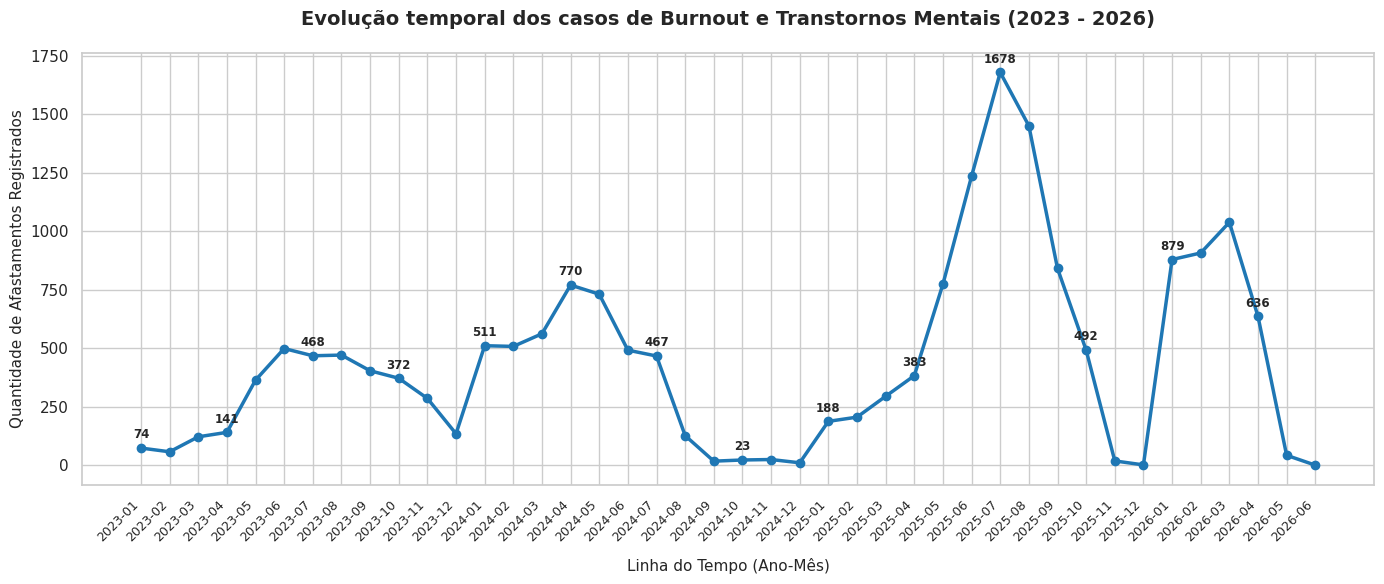

###### TOTAL DE CASOS POR ANO (2023 - 2026) #####
 ano  total_casos  crescimento_porcentagem
2023         3394                      NaN
2024         4245                25.073659
2025         7563                78.162544
2026         3504               -53.669179


In [ ]:
## Gerando o gráfico

plt.figure(figsize=(14, 6))
sns.set_theme(style='whitegrid')

# Linha principal
plt.plot(
    evolucao_mensal['ano_mes_str'],
    evolucao_mensal['total_casos'],
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    markersize=6,
    label='Casos Mensais',
)

# Adicionar rótulos nos picos/pontos principais
for i, row in evolucao_mensal.iterrows():
    # Destaca pontos de pico ou início/fim de anos
    if i % 3 == 0 or row['total_casos'] == evolucao_mensal['total_casos'].max():
        plt.annotate(
            f"{row['total_casos']}",
            (row['ano_mes_str'], row['total_casos']),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=8.5,
            weight='bold',
        )

plt.title(
    'Evolução temporal dos casos de Burnout e Transtornos Mentais (2023 - 2026)',
    fontsize=14,
    weight='bold',
    pad=20,
)
plt.xlabel('Linha do Tempo (Ano-Mês)', fontsize=11, labelpad=10)
plt.ylabel('Quantidade de Afastamentos Registrados', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

plt.show()

# 4. Tabela Resumo Consolidada por Ano
resumo_anual = (
    df_temporal[col_data]
    .dt.year.value_counts()
    .sort_index()
    .reset_index(name='total_casos')
    .rename(columns={col_data: 'ano'})
)
resumo_anual['crescimento_porcentagem'] = (
    resumo_anual['total_casos'].pct_change() * 100
)

print('###### TOTAL DE CASOS POR ANO (2023 - 2026) #####')
print(resumo_anual.to_string(index=False))

### Achados:

- **Explosão de Casos em 2025 (+78,16%)**: O volume quase dobrou de 2024 para 2025 (subindo de 4.245 para 7.563 registros), indicando uma aceleração expressiva nas notificações de afastamento por Burnout/Transtornos Mentais nesse período.


**- Ressalva Analítica sobre 2026 (-53,67%):** A queda observada em 2026 (3.504 casos) não indica redução real do risco ou melhora nos indicadores. **Trata-se de um viés temporário por conta do ano em andamento (base parcial)** e do delay natural de formalização e consolidação dos dados do INSS/CAT.


----------


## Para finalizar essa parte Análitica

Veremos o resultado do cruzamento demográfico vs profissional (Idade x CBO):

**Exemplo**: *O Burnout em Gestores atinge mais profissionais de meia-idade (40-50 anos), enquanto no Atendimento/Administrativo o pico está em jovens de 20-30 anos?*

In [ ]:
dados_burnout.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18706 entries, 0 to 18705
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   agente_causador       18706 non-null  object        
 1   data_acidente         18706 non-null  datetime64[ns]
 2   cbo_codigo            18706 non-null  object        
 3   cbo_descricao         18706 non-null  object        
 4   cid_codigo            18706 non-null  object        
 5   cid_descricao         18706 non-null  object        
 6   cnae_codigo           18706 non-null  int64         
 7   emitente_cat          18706 non-null  object        
 8   indica_obito          18706 non-null  object        
 9   municipio_empregador  18706 non-null  object        
 10  natureza_lesao        18706 non-null  object        
 11  origem_cadastramento  18706 non-null  object        
 12  parte_corpo_atingida  18706 non-null  object        
 13  genero          

##### Distribuiçao percentual % da faixa etária por cargo
faixa_etaria                                Até 18 anos  19-29 anos  30-39 anos  40-49 anos  50-59 anos
cbo_grupo_macro                                                                                        
Gestores_Diretores_Gerentes                        0.00        6.62       38.88       39.15       14.52
Profissionais_Especialistas_Nivel_Superior         0.00       11.56       44.34       33.01       10.04
Servicos_Administrativos_Atendimento               0.08       18.84       33.40       31.43       13.99


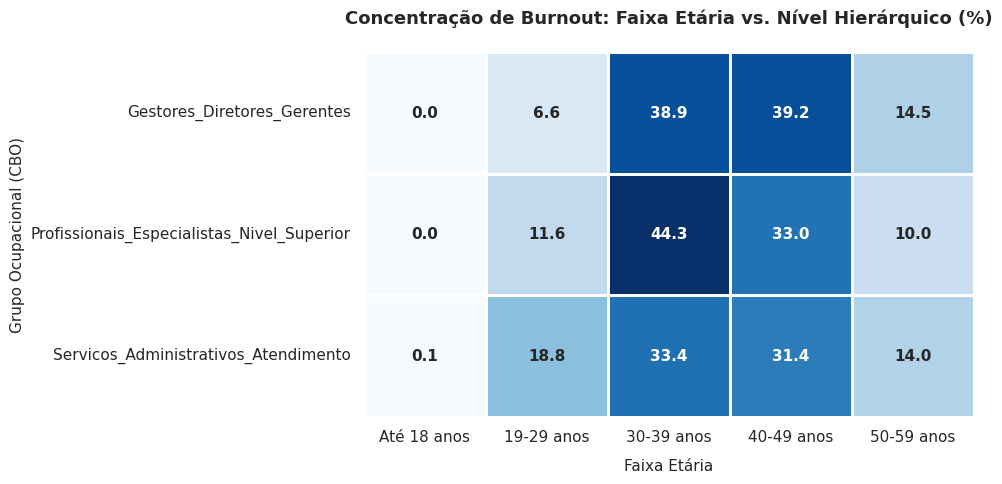

In [ ]:
# Garantindo a ordem das faixas etárias

ordem_faixa = [
    'Até 18 anos',
    '19-29 anos',
    '30-39 anos',
    '40-49 anos',
    '50-59 anos',
    '60-69 anos',
    '70+ anos',
]

## Filtro focado nos principais grupos do setor financeiro e administrativo
cargos_foco = [
    'Gestores_Diretores_Gerentes',
    'Profissionais_Especialistas_Nivel_Superior',
    'Servicos_Administrativos_Atendimento',
]

df_cruzamento = dados_burnout[
    dados_burnout['cbo_grupo_macro'].isin(cargos_foco)
].copy()


#### Tabela de cruzamento proporcional em %
tabela_cruzada = (
    pd.crosstab(
        df_cruzamento['cbo_grupo_macro'],
        df_cruzamento['faixa_etaria'],
        normalize='index',
    ) * 100
)

#Reordenar colunas conforme a ordem lógica da idade
cols_existente = [col for col in ordem_faixa if col in tabela_cruzada.columns]
tabela_cruzada = tabela_cruzada[cols_existente]

print('##### Distribuiçao percentual % da faixa etária por cargo')
print(tabela_cruzada.round(2).to_string())


### Montando o gráfico: usaremos o heatmap (Mapa de calor)

plt.figure(figsize=(10, 5))
sns.set_theme(style='white')

ax = sns.heatmap(
    tabela_cruzada,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'weight': 'bold', 'size': 11},
)

plt.title(
    'Concentração de Burnout: Faixa Etária vs. Nível Hierárquico (%)',
    fontsize=13,
    weight='bold',
    pad=20,
)
plt.xlabel('Faixa Etária', fontsize=11, labelpad=10)
plt.ylabel('Grupo Ocupacional (CBO)', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Revelação das faixas etárias gerais

- **Gestores_Diretores_Gerentes:** O pico absoluto está entre 40–49 anos (39,15%), seguido bem de perto por 30–39 anos (38,88%). Isso demonstra que o esgotamento atinge a liderança no momento de maior exigência decisória e acúmulo de responsabilidades na carreira.

- **Profissionais_Especialistas_Nivel_Superior:** Concentração massiva na faixa de 30–39 anos (44,34%), caindo para 33,01% na faixa de 40–49. É o retrato dos especialistas em ascensão técnica enfrentando altas cargas de entrega e metas operacionais.

- **Servicos_Administrativos_Atendimento:** Distribuição mais ampla nas faixas maduras, mantendo 33,40% (30–39 anos) e 31,43% (40–49 anos).

------

## Resumo geral da fase de Análise Exploratória

A análise exploratória conduzida sobre a base de dados tratada de licenças médicas e C**ATs (Comunicações de Acidente de Trabalho) ** identificou padrões críticos de assimetria geográfica, perfil demográfico desproporcional e gargalos regulatórios no registro de afastamentos.

O estudo desmistifica a premissa de que o volume de casos é proporcional apenas ao tamanho da população trabalhadora formal, revelando dinâmicas de precarização em polos descentralizados e forte pressão sobre cargos de gestão e especialistas seniores.

1. Principais Achados e Evidências dos Dados

A. **Perfil demográfico predominante "Gênero e Idade":** Os afastamentos por Burnout atingem predominantemente mulheres, com maior incidência concentrada nas faixas etárias de 30 a 49 anos.

B. **Desconexão Geográfica (Sede Corporativa vs. Operação Real) UF do Empregador (CNPJ Sede)**: São Paulo lidera com 41% dos casos (7.822 registros), seguido pelo Rio de Janeiro (2.500 registros), refletindo a concentração de matrizes corporativas no Sudeste.

**UF do Acidente (Local de Ocorrência Real):** O Maranhão concentra 42% dos casos totais (7.932 registros), seguido pelo Tocantins (2.520 registros).

Isso indica forte evidência de descentralização operacional e transferência de atividades intensivas/remotas do Sudeste para polos do Norte/Nordeste.

**C. Estrutura de Cargos e Setores Mais Impactados**:
O setor de *Serviços Financeiros e Bancos* é o principal vetor de afastamentos nos polos pesquisados.

Ao contrário do senso comum que atribui o burnout exclusivamente à base operacional, os cargos mais atingidos no setor financeiro são:

- **Profissionais Especialistas Nivel_Superior**: 1.450 casos

- **Gestores Diretores Gerentes**: 899 casos

- **Servicos Administrativos Atendimento**: 675 casos


**E. Tendência de Crescimento Histórico (2023–2026) aceleração em 2025:** Registrou-se um salto de 78,16% no volume de notificações de 2024 (4.245 casos) para 2025 (7.563 casos).

**Base Parcial em 2026:** *Os dados de 2026 (3.504 casos) representam a consolidação parcial do ano em andamento, não significando redução do risco real.*

**F. Cruzamento Risco Demográfico vs Nível Hierárquico 30–39 Anos:** Pico absoluto em Especialistas_Nivel_Superior (44,34%), refletindo alta carga técnica na fase de consolidação profissional.

**40–49 Anos:** Maior prevalência em Gestores_Diretores_Gerentes (39,15%), associado ao pico de responsabilidade decisória e gestão de equipes.